In [1]:
#Imports
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score

In [2]:
# Load the dataset
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#Class Distribution
print(df['Class'].value_counts())
print("Fraud ratio:", df['Class'].mean())

Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727485630620034


In [4]:
#Data Preprocessing
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [5]:
#Split Normal & Fraud
normal_df = df[df['Class'] == 0]
fraud_df = df[df['Class'] == 1]

print("Normal:", len(normal_df))
print("Fraud:", len(fraud_df))

Normal: 284315
Fraud: 492


In [6]:
#Train/Test Split
X_normal = normal_df.drop('Class', axis=1)

# Train ONLY on normal data
X_train, X_test_normal = train_test_split(
    X_normal, test_size=0.2, random_state=42
)

# Test set = normal + fraud
X_test = pd.concat([
    X_test_normal,
    fraud_df.drop('Class', axis=1)
])

y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(fraud_df))
])

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (227452, 30)
Test: (57355, 30)


In [7]:
#Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

In [8]:
#Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [9]:
#Initialize Model
input_dim = X_train.shape[1]

model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
#Train the autoencoder
epochs = 50
batch_size = 256

for epoch in range(epochs):
    for i in range(0, len(X_train_tensor), batch_size):
        batch = X_train_tensor[i:i+batch_size]
        
        output = model(batch)
        loss = criterion(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.5130
Epoch 2, Loss: 0.3710
Epoch 3, Loss: 0.3550
Epoch 4, Loss: 0.3423
Epoch 5, Loss: 0.3306
Epoch 6, Loss: 0.3226
Epoch 7, Loss: 0.3146
Epoch 8, Loss: 0.3057
Epoch 9, Loss: 0.2961
Epoch 10, Loss: 0.2842
Epoch 11, Loss: 0.2750
Epoch 12, Loss: 0.2676
Epoch 13, Loss: 0.2626
Epoch 14, Loss: 0.2604
Epoch 15, Loss: 0.2575
Epoch 16, Loss: 0.2556
Epoch 17, Loss: 0.2546
Epoch 18, Loss: 0.2542
Epoch 19, Loss: 0.2498
Epoch 20, Loss: 0.2475
Epoch 21, Loss: 0.2465
Epoch 22, Loss: 0.2459
Epoch 23, Loss: 0.2454
Epoch 24, Loss: 0.2453
Epoch 25, Loss: 0.2451
Epoch 26, Loss: 0.2450
Epoch 27, Loss: 0.2450
Epoch 28, Loss: 0.2449
Epoch 29, Loss: 0.2448
Epoch 30, Loss: 0.2450
Epoch 31, Loss: 0.2450
Epoch 32, Loss: 0.2445
Epoch 33, Loss: 0.2439
Epoch 34, Loss: 0.2436
Epoch 35, Loss: 0.2435
Epoch 36, Loss: 0.2430
Epoch 37, Loss: 0.2430
Epoch 38, Loss: 0.2433
Epoch 39, Loss: 0.2438
Epoch 40, Loss: 0.2443
Epoch 41, Loss: 0.2447
Epoch 42, Loss: 0.2455
Epoch 43, Loss: 0.2443
Epoch 44, Loss: 0.24

In [11]:
#Compute Reconstruction Error
with torch.no_grad():
    reconstructions = model(X_test_tensor)

errors = torch.mean((X_test_tensor - reconstructions)**2, dim=1)
errors = errors.numpy()

print("Sample errors:", errors[:10])

Sample errors: [0.08422902 0.08403024 0.27804175 0.13962427 0.33420166 0.23137239
 0.5109437  0.17829895 0.14852981 0.22953174]


In [12]:
#Baseline Threshold (95th percentile)
baseline_t = np.percentile(errors, 95)
y_pred_base = (errors > baseline_t).astype(int)

print("Baseline Results:")
print(classification_report(y_test, y_pred_base))

Baseline Results:
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     56863
         1.0       0.14      0.84      0.25       492

    accuracy                           0.96     57355
   macro avg       0.57      0.90      0.61     57355
weighted avg       0.99      0.96      0.97     57355



In [13]:
#Hill Climbing
def hill_climb(errors, y_true, step=None, max_iter=100):

    # Start from better threshold
    t = np.percentile(errors, 95)

    # Adaptive step size
    if step is None:
        step = np.std(errors) * 0.01

    best_score = 0
    best_t = t

    for _ in range(max_iter):

        y_pred = (errors > t).astype(int)
        score = f1_score(y_true, y_pred)

        t_plus = t + step
        t_minus = t - step

        y_pred_plus = (errors > t_plus).astype(int)
        y_pred_minus = (errors > t_minus).astype(int)

        score_plus = f1_score(y_true, y_pred_plus)
        score_minus = f1_score(y_true, y_pred_minus)

        if score_plus > score:
            t = t_plus
            score = score_plus
        elif score_minus > score:
            t = t_minus
            score = score_minus
        else:
            break

        if score > best_score:
            best_score = score
            best_t = t

    return best_t, best_score

In [14]:
#Run Hill Climbing
best_threshold, best_f1 = hill_climb(errors, y_test)

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 1.7890923
Best F1: 0.647887323943662


In [15]:
#Final Results
y_pred_opt = (errors > best_threshold).astype(int)

print("Optimized Results:")
print(classification_report(y_test, y_pred_opt))

Optimized Results:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     56863
         1.0       0.55      0.79      0.65       492

    accuracy                           0.99     57355
   macro avg       0.77      0.89      0.82     57355
weighted avg       0.99      0.99      0.99     57355



In [16]:
#Compare Baseline vs Optimized
print("Baseline F1:", f1_score(y_test, y_pred_base))
print("Optimized F1:", f1_score(y_test, y_pred_opt))

Baseline F1: 0.24702380952380953
Optimized F1: 0.647887323943662


In [17]:
# Block 17: Comparison Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------- Baseline Metrics --------
baseline_acc = accuracy_score(y_test, y_pred_base)
baseline_prec = precision_score(y_test, y_pred_base)
baseline_rec = recall_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)

# -------- Optimized Metrics --------
opt_acc = accuracy_score(y_test, y_pred_opt)
opt_prec = precision_score(y_test, y_pred_opt)
opt_rec = recall_score(y_test, y_pred_opt)
opt_f1 = f1_score(y_test, y_pred_opt)

# -------- Print Results --------
print("📊 Baseline (Autoencoder Only)")
print("Accuracy :", baseline_acc)
print("Precision:", baseline_prec)
print("Recall   :", baseline_rec)
print("F1 Score :", baseline_f1)

print("\n📊 Optimized (Autoencoder + Hill Climbing)")
print("Accuracy :", opt_acc)
print("Precision:", opt_prec)
print("Recall   :", opt_rec)
print("F1 Score :", opt_f1)

📊 Baseline (Autoencoder Only)
Accuracy : 0.9558887629674833
Precision: 0.14470013947001395
Recall   : 0.8434959349593496
F1 Score : 0.24702380952380953

📊 Optimized (Autoencoder + Hill Climbing)
Accuracy : 0.9925900095893994
Precision: 0.5468531468531469
Recall   : 0.7947154471544715
F1 Score : 0.647887323943662


In [18]:
# Block 18: Tabular Comparison

import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1],
    "Optimized": [opt_acc, opt_prec, opt_rec, opt_f1]
})

print(results)

      Metric  Baseline  Optimized
0   Accuracy  0.955889   0.992590
1  Precision  0.144700   0.546853
2     Recall  0.843496   0.794715
3   F1 Score  0.247024   0.647887


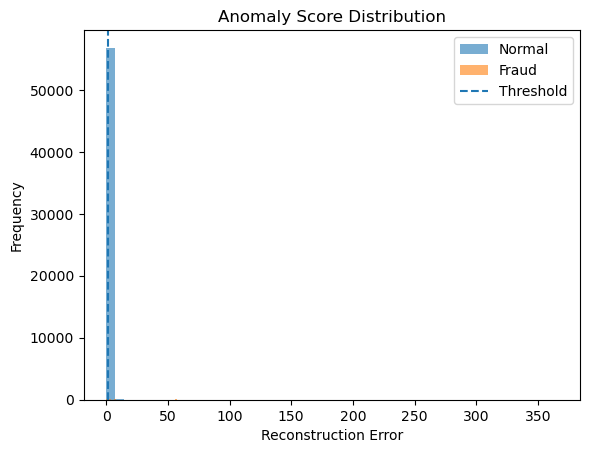

In [19]:
# Block 19: Error Distribution

import matplotlib.pyplot as plt

# Separate errors
errors_normal = errors[y_test == 0]
errors_fraud = errors[y_test == 1]

plt.figure()
plt.hist(errors_normal, bins=50, alpha=0.6, label="Normal")
plt.hist(errors_fraud, bins=50, alpha=0.6, label="Fraud")

plt.axvline(best_threshold, linestyle='--', label="Threshold")

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Anomaly Score Distribution")
plt.legend()
# ✅ SAVE FIGURE
plt.savefig("error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/7z/vdhdhk096pbdd7d5hxff6lrr0000gn/T/ipykernel_14162/4218479887.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([errors_normal, errors_fraud], labels=["Normal", "Fraud"])


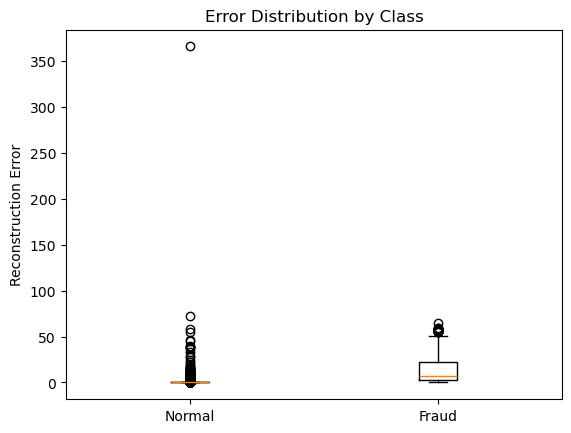

In [20]:
# Block 20: Box Plot

plt.figure()

plt.boxplot([errors_normal, errors_fraud], labels=["Normal", "Fraud"])

plt.ylabel("Reconstruction Error")
plt.title("Error Distribution by Class")
# ✅ SAVE FIGURE
plt.savefig("boxplot_error_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

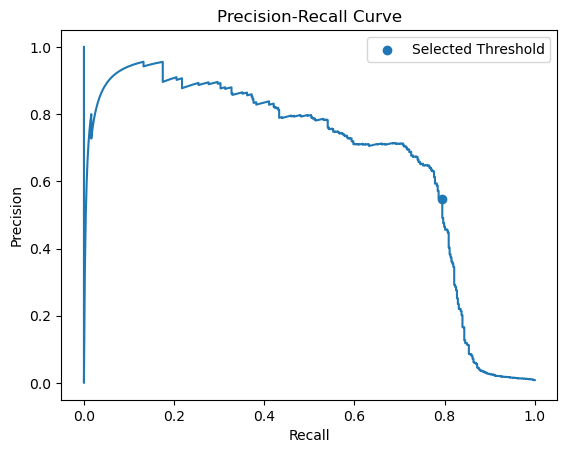

In [21]:
# Block 21: Precision-Recall Curve (Saved & Improved)

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, errors)

plt.figure()

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

# ✅ Optional: highlight operating point (your threshold)
y_pred_opt = (errors > best_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score

p_opt = precision_score(y_test, y_pred_opt)
r_opt = recall_score(y_test, y_pred_opt)

plt.scatter(r_opt, p_opt, marker='o', label="Selected Threshold")
plt.legend()

# ✅ SAVE FIGURE
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches='tight')
plt.savefig("precision_recall_curve.pdf", bbox_inches='tight')

plt.show()

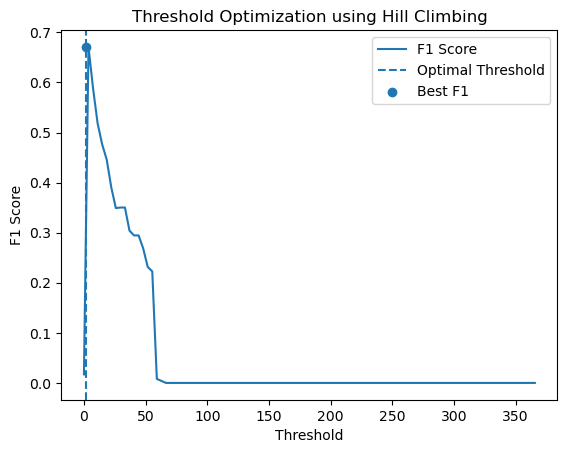

In [22]:
# Block 22: Threshold vs F1 Score (Saved & Improved)

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(min(errors), max(errors), 100)
f1_scores = []

for t in thresholds:
    y_pred_temp = (errors > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_temp))

plt.figure()

plt.plot(thresholds, f1_scores, label="F1 Score")

# ✅ Mark optimal threshold
plt.axvline(best_threshold, linestyle='--', label="Optimal Threshold")

# ✅ Mark best point
plt.scatter(best_threshold, max(f1_scores), marker='o', label="Best F1")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Optimization using Hill Climbing")

plt.legend()

# ✅ SAVE FIGURE
plt.savefig("threshold_vs_f1.png", dpi=300, bbox_inches='tight')
plt.savefig("threshold_vs_f1.pdf", bbox_inches='tight')

plt.show()

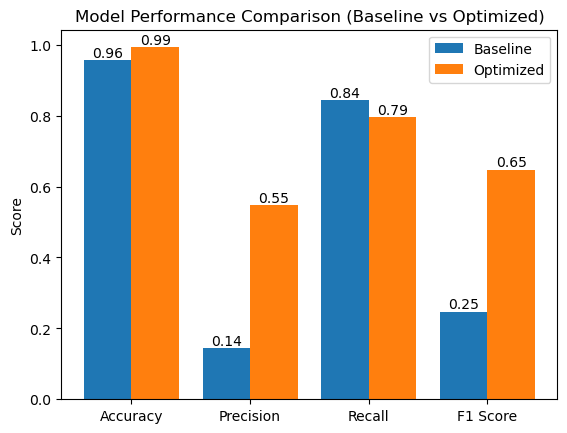

In [23]:
# Block 23: Metrics Comparison Plot (Saved & Improved)

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

baseline_values = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
optimized_values = [opt_acc, opt_prec, opt_rec, opt_f1]

x = np.arange(len(metrics))

plt.figure()

bars1 = plt.bar(x - 0.2, baseline_values, width=0.4, label="Baseline")
bars2 = plt.bar(x + 0.2, optimized_values, width=0.4, label="Optimized")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison (Baseline vs Optimized)")

# ✅ Add value labels on bars (VERY PROFESSIONAL)
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.2f}", ha='center', va='bottom')

plt.legend()

# ✅ SAVE FIGURE
plt.savefig("metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig("metrics_comparison.pdf", bbox_inches='tight')

plt.show()

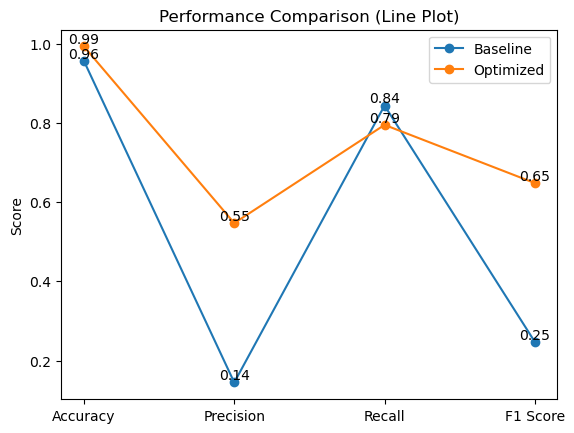

In [24]:
# Block 24: Line Comparison Plot (Saved & Improved)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(metrics, baseline_values, marker='o', label="Baseline")
plt.plot(metrics, optimized_values, marker='o', label="Optimized")

plt.ylabel("Score")
plt.title("Performance Comparison (Line Plot)")

# ✅ Add value labels (very useful)
for i, v in enumerate(baseline_values):
    plt.text(metrics[i], v, f"{v:.2f}", ha='center', va='bottom')

for i, v in enumerate(optimized_values):
    plt.text(metrics[i], v, f"{v:.2f}", ha='center', va='bottom')

plt.legend()

# ✅ SAVE FIGURE
plt.savefig("metrics_line_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("metrics_line_plot.pdf", bbox_inches='tight')

plt.show()

In [25]:
# Block 25: Clean Table

import pandas as pd

df_results = pd.DataFrame({
    "Metric": metrics,
    "Baseline": baseline_values,
    "Optimized": optimized_values
})

df_results.set_index("Metric", inplace=True)
print(df_results)

           Baseline  Optimized
Metric                        
Accuracy   0.955889   0.992590
Precision  0.144700   0.546853
Recall     0.843496   0.794715
F1 Score   0.247024   0.647887


In [26]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [27]:
print(X_train.shape)

(227452, 30)


In [28]:
print(np.unique(y_test))

[0. 1.]


In [29]:
fraud_df = df[df['Class'] == 1]

In [30]:
print(len(fraud_df))

492
